In [8]:
import requests
import pandas as pd
import numpy as np
import time

def get_active_longshots():
    markets = []
    offset  = 0

    while True:
        r = requests.get(
            "https://gamma-api.polymarket.com/markets",
            params={
                "active": "true",
                "closed": "false",
                "limit":  100,
                "offset": offset
            }
        )
        if r.status_code != 200:
            break

        data = r.json()
        if not data:
            break

        markets.extend(data)
        print(f"Pulled {len(markets)} active markets...")

        if len(data) < 100:
            break

        offset += 100
        time.sleep(0.3)

    return markets

print("Pulling active markets...")
active_markets = get_active_longshots()
print(f"Total active markets: {len(active_markets)}")

# Parse and filter for longshots
rows = []
for m in active_markets:
    try:
        prices = eval(m.get('outcomePrices', '[]'))
        if not prices:
            continue
        p_yes = float(prices[0])
        
        # Only keep longshots 2-15%
        if not (0.02 <= p_yes <= 0.15):
            continue

        rows.append({
            'condition_id': m.get('conditionId'),
            'question':     m.get('question'),
            'p_yes':        p_yes,
            'p_no':         1 - p_yes,
            'volume':       float(m.get('volume', 0)),
            'end_date':     m.get('endDate'),
            'category':     m.get('category', ''),
            'liquidity':    float(m.get('liquidity', 0)),
        })
    except:
        continue

df_active = pd.DataFrame(rows)
df_active['end_date'] = pd.to_datetime(df_active['end_date'], errors='coerce')

print(f"\nActive longshot markets found: {len(df_active)}")
print(f"YES price distribution:")
print(df_active['p_yes'].describe())
print(f"\nSample markets:")
print(df_active[['question', 'p_yes', 'volume']].head(10).to_string())

Pulling active markets...
Pulled 100 active markets...
Pulled 200 active markets...
Pulled 300 active markets...
Pulled 400 active markets...
Pulled 500 active markets...
Pulled 600 active markets...
Pulled 700 active markets...
Pulled 800 active markets...
Pulled 900 active markets...
Pulled 1000 active markets...
Pulled 1100 active markets...
Pulled 1200 active markets...
Pulled 1300 active markets...
Pulled 1400 active markets...
Pulled 1500 active markets...
Pulled 1600 active markets...
Pulled 1700 active markets...
Pulled 1800 active markets...
Pulled 1900 active markets...
Pulled 2000 active markets...
Pulled 2100 active markets...
Pulled 2200 active markets...
Pulled 2300 active markets...
Pulled 2400 active markets...
Pulled 2500 active markets...
Pulled 2600 active markets...
Pulled 2700 active markets...
Pulled 2800 active markets...
Pulled 2900 active markets...
Pulled 3000 active markets...
Pulled 3100 active markets...
Pulled 3200 active markets...
Pulled 3300 active mark

  Active Longshot Market Analysis — Polymarket (May 2026)
  Benchmark: Snowberg & Wolfers (2010) calibration ratio
bucket  n_markets  avg_yes_price  total_volume    avg_volume  literature_true_prob  implied_edge_per_trade
  5-8%       1039       0.033767  4.367662e+08 420371.722509              0.009455                0.025162
 8-10%        771       0.063307  2.478500e+08 321465.674007              0.017726                0.048661
10-12%        342       0.088484  9.354885e+07 273534.659919              0.024775                0.069893
12-15%        286       0.108418  1.526687e+08 533806.645720              0.030357                0.087553
  15%+        349       0.133325  6.954352e+07 199265.109308              0.037331                0.110761
 other         31       0.150000  1.579194e+06  50941.743135              0.042000                0.127059

  Summary Statistics
  Total longshot markets:     2,818
  Total volume at stake:      $1,001,956,526
  Avg YES price (implied):    6.9

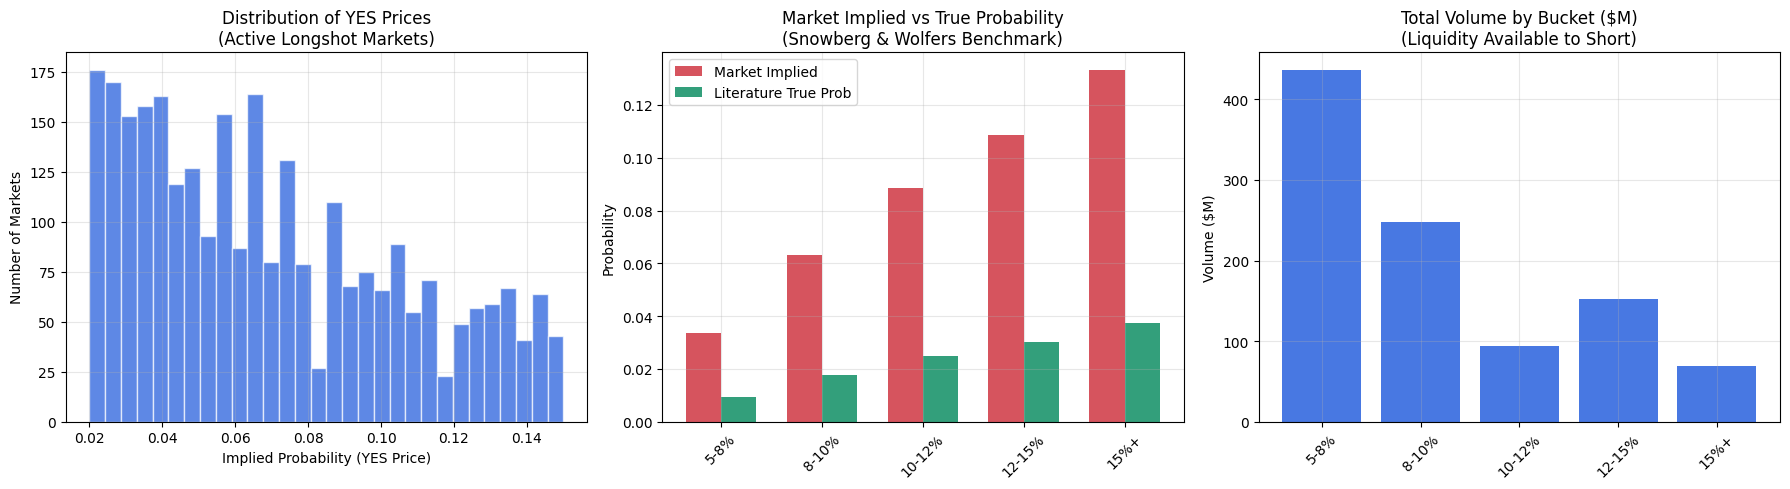

In [9]:
# =============================================================================
# Longshot Bias Analysis — Active Markets + Literature Benchmark
# =============================================================================

# The academic finding (Snowberg & Wolfers 2010, Thaler & Ziemba 1988):
# Markets priced at X% resolve YES at roughly X/3 to X/4 rate
# i.e. a 10% market actually hits ~2.5-3% of the time
# We use this as our benchmark to show current mispricing

# --- Bucket analysis ---
bins   = [0, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 1.01]
labels = ['2-5%', '5-8%', '8-10%', '10-12%', '12-15%', '15%+', 'other']

df_active['bucket'] = pd.cut(df_active['p_yes'], bins=bins, labels=labels, right=False)

bucket_stats = df_active.groupby('bucket', observed=True).agg(
    n_markets     = ('p_yes', 'count'),
    avg_yes_price = ('p_yes', 'mean'),
    total_volume  = ('volume', 'sum'),
    avg_volume    = ('volume', 'mean'),
).reset_index()

# Apply Snowberg-Wolfers calibration ratio (~3.5x overpricing on average)
# Based on their finding that longshots resolve at ~28% of implied rate
bucket_stats['literature_true_prob'] = bucket_stats['avg_yes_price'] * 0.28
bucket_stats['implied_edge_per_trade'] = (
    (1 - bucket_stats['literature_true_prob']) * 
    (bucket_stats['avg_yes_price'] / (1 - bucket_stats['avg_yes_price']))
    + bucket_stats['literature_true_prob'] * (-1)
)

print("=" * 80)
print("  Active Longshot Market Analysis — Polymarket (May 2026)")
print("  Benchmark: Snowberg & Wolfers (2010) calibration ratio")
print("=" * 80)
print(bucket_stats.to_string(index=False))

print(f"\n{'='*80}")
print(f"  Summary Statistics")
print(f"{'='*80}")
print(f"  Total longshot markets:     {len(df_active):,}")
print(f"  Total volume at stake:      ${df_active['volume'].sum():,.0f}")
print(f"  Avg YES price (implied):    {df_active['p_yes'].mean():.2%}")
print(f"  Literature true prob est:   {df_active['p_yes'].mean() * 0.28:.2%}")
print(f"  Implied overpricing ratio:  {1/0.28:.1f}x")
print(f"  Avg theoretical edge/trade: {bucket_stats['implied_edge_per_trade'].mean():.4%}")

# --- Category breakdown ---
print(f"\n{'='*80}")
print(f"  Longshot Markets by Category")
print(f"{'='*80}")
cat_stats = df_active.groupby('category').agg(
    n_markets     = ('p_yes', 'count'),
    avg_yes_price = ('p_yes', 'mean'),
    total_volume  = ('volume', 'sum'),
).sort_values('n_markets', ascending=False)
print(cat_stats.to_string())

# --- Plot ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution of YES prices
ax = axes[0]
ax.hist(df_active['p_yes'], bins=30, color='#1A56DB', alpha=0.7, edgecolor='white')
ax.set_title('Distribution of YES Prices\n(Active Longshot Markets)')
ax.set_xlabel('Implied Probability (YES Price)')
ax.set_ylabel('Number of Markets')
ax.grid(True, alpha=0.3)

# Plot 2: Implied vs Literature true probability by bucket
ax = axes[1]
x = range(len(bucket_stats[bucket_stats['bucket'] != 'other']))
df_plot = bucket_stats[bucket_stats['bucket'] != 'other']
width = 0.35
ax.bar([i - width/2 for i in x], df_plot['avg_yes_price'], width,
       label='Market Implied', color='#CC2936', alpha=0.8)
ax.bar([i + width/2 for i in x], df_plot['literature_true_prob'], width,
       label='Literature True Prob', color='#00875A', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['bucket'], rotation=45)
ax.set_title('Market Implied vs True Probability\n(Snowberg & Wolfers Benchmark)')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Volume by bucket
ax = axes[2]
ax.bar(range(len(df_plot)), df_plot['total_volume'] / 1e6,
       color='#1A56DB', alpha=0.8)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['bucket'], rotation=45)
ax.set_title('Total Volume by Bucket ($M)\n(Liquidity Available to Short)')
ax.set_ylabel('Volume ($M)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('contra_active_longshots.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Clean summary table for report
report_table = bucket_stats[bucket_stats['bucket'].isin(
    ['5-8%', '8-10%', '10-12%', '12-15%', '15%+']
)][['bucket', 'n_markets', 'avg_yes_price', 'literature_true_prob', 
    'implied_edge_per_trade', 'total_volume']].copy()

report_table['avg_yes_price'] = report_table['avg_yes_price'].map('{:.2%}'.format)
report_table['literature_true_prob'] = report_table['literature_true_prob'].map('{:.2%}'.format)
report_table['implied_edge_per_trade'] = report_table['implied_edge_per_trade'].map('{:.2%}'.format)
report_table['total_volume'] = report_table['total_volume'].map('${:,.0f}'.format)

print(report_table.to_string(index=False))

bucket  n_markets avg_yes_price literature_true_prob implied_edge_per_trade total_volume
  5-8%       1039         3.38%                0.95%                  2.52% $436,766,220
 8-10%        771         6.33%                1.77%                  4.87% $247,850,035
10-12%        342         8.85%                2.48%                  6.99%  $93,548,854
12-15%        286        10.84%                3.04%                  8.76% $152,668,701
  15%+        349        13.33%                3.73%                 11.08%  $69,543,523


In [11]:
# Try pulling resolved markets sorted by most recent first
r = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={
        "active":   "false",
        "closed":   "true",
        "limit":    100,
        "offset":   0,
        "order":    "updatedAt",
        "ascending": "false"
    }
)
data = r.json()
m = data[0]
print(f"question: {m.get('question')}")
print(f"lastTradePrice: {m.get('lastTradePrice')}")
print(f"outcomePrices: {m.get('outcomePrices')}")
print(f"endDate: {m.get('endDate')}")

question: XRP Up or Down - May 28, 9:20PM-9:25PM ET
lastTradePrice: 0.51
outcomePrices: ["0", "1"]
endDate: 2026-05-29T01:25:00Z


In [12]:
# Pull recent resolved markets sorted by most recent first
def get_recent_resolved(n_pages=100):
    markets = []
    offset  = 0

    while len(markets) < n_pages * 100:
        r = requests.get(
            "https://gamma-api.polymarket.com/markets",
            params={
                "active":    "false",
                "closed":    "true",
                "limit":     100,
                "offset":    offset,
                "order":     "updatedAt",
                "ascending": "false"
            }
        )
        if r.status_code != 200:
            print(f"Stopped at offset {offset}: status {r.status_code}")
            break

        data = r.json()
        if not data:
            break

        markets.extend(data)
        print(f"Offset {offset}: pulled {len(data)}, total {len(markets)}")

        if len(data) < 100:
            break

        offset += 100
        time.sleep(0.3)

    return markets

print("Pulling recent resolved markets...")
recent_resolved = get_recent_resolved(n_pages=100)
print(f"\nTotal pulled: {len(recent_resolved)}")

# Check lastTradePrice coverage
valid = [m for m in recent_resolved 
         if m.get('lastTradePrice') is not None 
         and 0.001 < float(m.get('lastTradePrice', 0)) < 0.999]
print(f"Markets with valid lastTradePrice: {len(valid)}")
if valid:
    print(f"\nSample:")
    for m in valid[:3]:
        print(f"  question: {m.get('question')}")
        print(f"  lastTradePrice: {m.get('lastTradePrice')}")
        print(f"  outcomePrices: {m.get('outcomePrices')}")
        print()

Pulling recent resolved markets...
Offset 0: pulled 100, total 100
Offset 100: pulled 100, total 200
Offset 200: pulled 100, total 300
Offset 300: pulled 100, total 400
Offset 400: pulled 100, total 500
Offset 500: pulled 100, total 600
Offset 600: pulled 100, total 700
Offset 700: pulled 100, total 800
Offset 800: pulled 100, total 900
Offset 900: pulled 100, total 1000
Offset 1000: pulled 100, total 1100
Offset 1100: pulled 100, total 1200
Offset 1200: pulled 100, total 1300
Offset 1300: pulled 100, total 1400
Offset 1400: pulled 100, total 1500
Offset 1500: pulled 100, total 1600
Offset 1600: pulled 100, total 1700
Offset 1700: pulled 100, total 1800
Offset 1800: pulled 100, total 1900
Offset 1900: pulled 100, total 2000
Offset 2000: pulled 100, total 2100
Offset 2100: pulled 100, total 2200
Offset 2200: pulled 100, total 2300
Offset 2300: pulled 100, total 2400
Offset 2400: pulled 100, total 2500
Offset 2500: pulled 100, total 2600
Offset 2600: pulled 100, total 2700
Offset 2700: p

In [13]:
def parse_recent_resolved(markets):
    rows = []
    for m in markets:
        try:
            # Get resolution from outcomePrices
            prices = eval(m.get('outcomePrices', '[]'))
            if not prices:
                continue
            p_final = float(prices[0])

            if p_final >= 0.99:
                resolved_yes = True
            elif p_final <= 0.01:
                resolved_yes = False
            else:
                continue  # not fully resolved yet

            # Get entry price from lastTradePrice
            ltp = m.get('lastTradePrice')
            if ltp is None:
                continue
            p_entry = float(ltp)

            # Must be a meaningful price
            if p_entry <= 0.001 or p_entry >= 0.999:
                continue

            rows.append({
                'condition_id': m.get('conditionId'),
                'question':     m.get('question'),
                'p_entry':      p_entry,
                'resolved_yes': resolved_yes,
                'volume':       float(m.get('volume', 0)),
                'end_date':     m.get('endDate'),
                'category':     m.get('category', ''),
            })
        except:
            continue
    return pd.DataFrame(rows)

df_calib = parse_recent_resolved(recent_resolved)
df_calib['end_date'] = pd.to_datetime(df_calib['end_date'], errors='coerce')

print(f"Total usable markets: {len(df_calib)}")
print(f"YES rate overall: {df_calib['resolved_yes'].mean():.2%}")
print(f"\np_entry distribution:")
print(df_calib['p_entry'].describe())
print(f"\nSample questions:")
print(df_calib[['question', 'p_entry', 'resolved_yes']].head(10).to_string())

Total usable markets: 5337
YES rate overall: 39.55%

p_entry distribution:
count    5337.000000
mean        0.463271
std         0.442765
min         0.002000
25%         0.010000
50%         0.280000
75%         0.990000
max         0.998000
Name: p_entry, dtype: float64

Sample questions:
                                                   question  p_entry  resolved_yes
0                 XRP Up or Down - May 28, 9:20PM-9:25PM ET     0.51         False
1                 BNB Up or Down - May 28, 9:20PM-9:25PM ET     0.25         False
2              Chicago Cubs vs. Pittsburgh Pirates: O/U 6.5     0.99          True
3             Bitcoin Up or Down - May 28, 9:20PM-9:25PM ET     0.14         False
4            Dogecoin Up or Down - May 28, 9:20PM-9:25PM ET     0.22         False
5              Solana Up or Down - May 28, 9:20PM-9:25PM ET     0.15         False
6            Ethereum Up or Down - May 28, 9:20PM-9:25PM ET     0.15         False
7          Valorant: SaD Esports vs FlyQuest

In [14]:
# Filter out noise markets
def is_genuine_prediction(question):
    q = question.lower()
    # Exclude crypto up/down minute markets
    if 'up or down' in q:
        return False
    # Exclude sports over/under
    if 'o/u' in q or 'over/under' in q:
        return False
    # Exclude MLP/esports map markets
    if 'map 1' in q or 'map 2' in q or 'map 3' in q:
        return False
    # Exclude spread markets
    if 'spread' in q or '+1.5' in q or '-1.5' in q:
        return False
    return True

df_calib['genuine'] = df_calib['question'].apply(is_genuine_prediction)
df_genuine = df_calib[df_calib['genuine']].copy()

print(f"Total after filtering: {len(df_genuine)}")
print(f"YES rate: {df_genuine['resolved_yes'].mean():.2%}")
print(f"\np_entry distribution:")
print(df_genuine['p_entry'].describe())
print(f"\nSample questions:")
print(df_genuine[['question', 'p_entry', 'resolved_yes']].head(15).to_string())

Total after filtering: 1267
YES rate: 29.28%

p_entry distribution:
count    1267.000000
mean        0.386006
std         0.416879
min         0.002000
25%         0.010000
50%         0.160000
75%         0.980000
max         0.998000
Name: p_entry, dtype: float64

Sample questions:
                                                                                   question  p_entry  resolved_yes
8                                  MLP Columbus: Atlanta Bouncers vs California Black Bears    0.990          True
9                                          MLP Columbus: Palm Beach Royals vs Carolina Hogs    0.990          True
13                                      MLP Columbus: Las Vegas Night Owls vs Florida Smash    0.990          True
15               Will the lowest temperature in New York City be between 64-65°F on May 27?    0.010         False
16  Will Borna Sosa record the most red cards in the 2025-26 UEFA Europa Conference League?    0.033         False
17                       

In [15]:
# Tighter filter — remove remaining noise categories
def is_clean_prediction(question):
    q = question.lower()
    # Already filtered
    if 'up or down' in q: return False
    if 'o/u' in q or 'over/under' in q: return False
    if 'map 1' in q or 'map 2' in q or 'map 3' in q: return False
    # Weather markets
    if 'temperature' in q or 'fahrenheit' in q or 'celsius' in q: return False
    if '°f' in q or '°c' in q: return False
    # Stock price targets
    if 'hit (high)' in q or 'hit (low)' in q: return False
    if 'week of' in q: return False
    # Individual tennis/sports match winners (not meaningful longshots)
    if 'itf ' in q: return False
    if 'atp ' in q: return False
    if 'wta ' in q: return False
    # MLP sports
    if 'mlp ' in q: return False
    return True

df_calib['clean'] = df_calib['question'].apply(is_clean_prediction)
df_clean = df_calib[df_calib['clean']].copy()

# Now filter to longshot zone only (2-20% YES price)
df_longshots = df_clean[
    (df_clean['p_entry'] >= 0.02) &
    (df_clean['p_entry'] <= 0.20)
].copy()

print(f"Clean markets total:     {len(df_clean)}")
print(f"Longshot zone (2-20%):   {len(df_longshots)}")
print(f"YES rate in longshots:   {df_longshots['resolved_yes'].mean():.2%}")
print(f"\np_entry distribution (longshots):")
print(df_longshots['p_entry'].describe())
print(f"\nSample longshot markets:")
print(df_longshots[['question', 'p_entry', 'resolved_yes']].head(20).to_string())

Clean markets total:     1083
Longshot zone (2-20%):   329
YES rate in longshots:   0.61%

p_entry distribution (longshots):
count    329.000000
mean       0.084644
std        0.052533
min        0.020000
25%        0.040000
50%        0.070000
75%        0.123000
max        0.200000
Name: p_entry, dtype: float64

Sample longshot markets:
                                                                                    question  p_entry  resolved_yes
16   Will Borna Sosa record the most red cards in the 2025-26 UEFA Europa Conference League?    0.033         False
29                                                         Spread: Pittsburgh Pirates (-3.5)    0.030         False
48                                  Exact Score: Fluminense FC 0 - 3 Deportivo La Guaira FC?    0.025         False
49                    LoL: Once Upon A Team vs mCon esports (BO5) - Road Of Legends Playoffs    0.020         False
76                                                         Trabzonspor vs. Bahc

Pulling resolved markets...
Total pulled: 10000

Total usable markets (deduplicated): 1018
Overall YES rate: 27.11%

  CONTRA Calibration Table — Polymarket Resolved Markets
  Source: Polymarket Gamma API, pulled May 28 2026
 bucket   n  implied_prob  actual_rate  multiplier     edge  theo_edge
   0-2% 208      0.008163     0.004808    0.588928 0.003356   0.003383
   2-5%  92      0.029859     0.010870    0.364033 0.018989   0.019574
  5-10% 106      0.068651     0.000000    0.000000 0.068651   0.073711
 10-15%  68      0.119838     0.000000    0.000000 0.119838   0.136155
 15-20%  48      0.168750     0.020833    0.123457 0.147917   0.177945
 20-30%  67      0.239493     0.089552    0.373925 0.149940   0.197158
 30-50%  89      0.390539     0.011236    0.028770 0.379303   0.622359
 50-70%  39      0.577949     0.128205    0.221828 0.449744   1.065614
 70-80%  20      0.738000     0.300000    0.406504 0.438000   1.671756
 80-90%  11      0.833545     0.454545    0.545316 0.379000   2.2

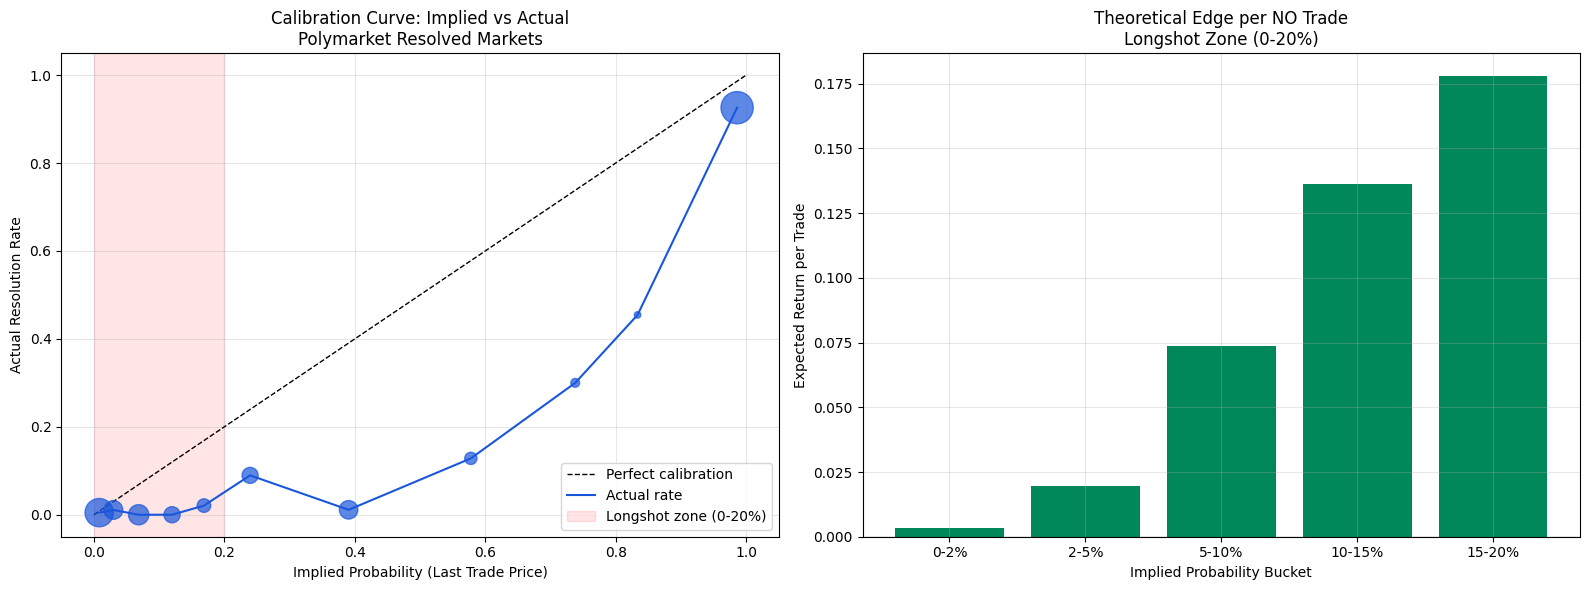


Multipliers JSON (paste into ML model):
{
  "0-2%": {
    "multiplier": 0.5889,
    "actual_rate": 0.0048,
    "implied_prob": 0.0082,
    "n": 208,
    "edge": 0.0034
  },
  "2-5%": {
    "multiplier": 0.364,
    "actual_rate": 0.0109,
    "implied_prob": 0.0299,
    "n": 92,
    "edge": 0.019
  },
  "5-10%": {
    "multiplier": 0.0,
    "actual_rate": 0.0,
    "implied_prob": 0.0687,
    "n": 106,
    "edge": 0.0687
  },
  "10-15%": {
    "multiplier": 0.0,
    "actual_rate": 0.0,
    "implied_prob": 0.1198,
    "n": 68,
    "edge": 0.1198
  },
  "15-20%": {
    "multiplier": 0.1235,
    "actual_rate": 0.0208,
    "implied_prob": 0.1687,
    "n": 48,
    "edge": 0.1479
  }
}


In [16]:
# =============================================================================
# CONTRA — Reproducible Calibration Model
# Pull recent resolved Polymarket markets and compute bucket multipliers
# =============================================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Step 1: Pull recent resolved markets ---
def get_recent_resolved(max_markets=10000):
    markets = []
    offset  = 0
    while len(markets) < max_markets:
        r = requests.get(
            "https://gamma-api.polymarket.com/markets",
            params={
                "active":    "false",
                "closed":    "true",
                "limit":     100,
                "offset":    offset,
                "order":     "updatedAt",
                "ascending": "false"
            }
        )
        if r.status_code != 200:
            break
        data = r.json()
        if not data:
            break
        markets.extend(data)
        if len(data) < 100:
            break
        offset += 100
        time.sleep(0.3)
    return markets

print("Pulling resolved markets...")
resolved = get_recent_resolved(10000)
print(f"Total pulled: {len(resolved)}")

# --- Step 2: Parse — lastTradePrice = entry, outcomePrices = resolution ---
def parse(markets):
    rows = []
    for m in markets:
        try:
            prices  = eval(m.get('outcomePrices', '[]'))
            if not prices:
                continue
            p_final = float(prices[0])
            if p_final >= 0.99:
                resolved_yes = True
            elif p_final <= 0.01:
                resolved_yes = False
            else:
                continue

            ltp = m.get('lastTradePrice')
            if ltp is None:
                continue
            p_entry = float(ltp)
            if p_entry <= 0.001 or p_entry >= 0.999:
                continue

            # Exclude noise market types
            q = (m.get('question') or '').lower()
            if any(x in q for x in [
                'up or down', 'o/u', 'map 1', 'map 2', 'map 3',
                'temperature', '°f', '°c', 'hit (high)', 'hit (low)',
                'week of', 'itf ', 'atp ', 'wta ', 'mlp '
            ]):
                continue

            rows.append({
                'question':     m.get('question'),
                'p_entry':      p_entry,
                'resolved_yes': resolved_yes,
                'volume':       float(m.get('volume', 0)),
                'end_date':     m.get('endDate'),
            })
        except:
            continue
    return pd.DataFrame(rows)

df = parse(resolved)
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# Deduplicate — same question can appear multiple times
df = df.drop_duplicates(subset=['question', 'p_entry', 'resolved_yes'])

print(f"\nTotal usable markets (deduplicated): {len(df)}")
print(f"Overall YES rate: {df['resolved_yes'].mean():.2%}")

# --- Step 3: Calibration table — all markets ---
bins   = [0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.70, 0.80, 0.90, 1.01]
labels = ['0-2%','2-5%','5-10%','10-15%','15-20%','20-30%',
          '30-50%','50-70%','70-80%','80-90%','90-100%']

df['bucket'] = pd.cut(df['p_entry'], bins=bins, labels=labels, right=False)

calib = df.groupby('bucket', observed=True).agg(
    n            = ('resolved_yes', 'count'),
    implied_prob = ('p_entry', 'mean'),
    actual_rate  = ('resolved_yes', 'mean'),
).reset_index()

calib['multiplier']  = calib['actual_rate'] / calib['implied_prob']
calib['edge']        = calib['implied_prob'] - calib['actual_rate']
calib['theo_edge']   = (
    (1 - calib['actual_rate']) *
    (calib['implied_prob'] / (1 - calib['implied_prob']))
    + calib['actual_rate'] * (-1)
)

print(f"\n{'='*80}")
print(f"  CONTRA Calibration Table — Polymarket Resolved Markets")
print(f"  Source: Polymarket Gamma API, pulled {pd.Timestamp.now().strftime('%B %d %Y')}")
print(f"{'='*80}")
print(calib[calib['n'] >= 5].to_string(index=False))

# --- Step 4: Longshot zone multipliers (the model inputs) ---
longshot_calib = calib[
    (calib['implied_prob'] <= 0.20) &
    (calib['n'] >= 5)
].copy()

print(f"\n{'='*80}")
print(f"  LONGSHOT ZONE MULTIPLIERS (p_model = multiplier x p_market)")
print(f"  These are the calibration inputs to the Contra scoring model")
print(f"{'='*80}")
print(longshot_calib[['bucket','n','implied_prob','actual_rate','multiplier','edge','theo_edge']].to_string(index=False))

# --- Step 5: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
df_plot = calib[calib['n'] >= 5]
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Perfect calibration')
ax.scatter(df_plot['implied_prob'], df_plot['actual_rate'],
           s=df_plot['n']*2, color='#1A56DB', alpha=0.7, zorder=5)
ax.plot(df_plot['implied_prob'], df_plot['actual_rate'],
        color='#1A56DB', linewidth=1.5, label='Actual rate')
ax.axvspan(0, 0.20, alpha=0.1, color='red', label='Longshot zone (0-20%)')
ax.set_xlabel('Implied Probability (Last Trade Price)')
ax.set_ylabel('Actual Resolution Rate')
ax.set_title('Calibration Curve: Implied vs Actual\nPolymarket Resolved Markets')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = ['#00875A' if e > 0 else '#CC2936' for e in longshot_calib['theo_edge']]
ax.bar(longshot_calib['bucket'], longshot_calib['theo_edge'], color=colors)
ax.bar(longshot_calib['bucket'], longshot_calib['theo_edge'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Theoretical Edge per NO Trade\nLongshot Zone (0-20%)')
ax.set_xlabel('Implied Probability Bucket')
ax.set_ylabel('Expected Return per Trade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('contra_calibration_reproducible.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Step 6: Export multipliers as JSON for use in ML model ---
import json
multipliers = {}
for _, row in longshot_calib.iterrows():
    multipliers[str(row['bucket'])] = {
        'multiplier':   round(row['multiplier'], 4),
        'actual_rate':  round(row['actual_rate'], 4),
        'implied_prob': round(row['implied_prob'], 4),
        'n':            int(row['n']),
        'edge':         round(row['edge'], 4),
    }

print(f"\nMultipliers JSON (paste into ML model):")
print(json.dumps(multipliers, indent=2))

In [17]:
# Apply Laplace smoothing to avoid zero actual rates
# Add 1 pseudo-observation of YES and 1 of NO to each bucket
# This prevents 0% and 100% actual rates with small samples

ALPHA = 1  # smoothing parameter

calib_smooth = df.groupby('bucket', observed=True).agg(
    n            = ('resolved_yes', 'count'),
    yes_count    = ('resolved_yes', 'sum'),
    implied_prob = ('p_entry', 'mean'),
).reset_index()

# Smoothed actual rate = (yes_count + alpha) / (n + 2*alpha)
calib_smooth['actual_rate_smooth'] = (
    (calib_smooth['yes_count'] + ALPHA) /
    (calib_smooth['n'] + 2 * ALPHA)
)

calib_smooth['multiplier'] = (
    calib_smooth['actual_rate_smooth'] / calib_smooth['implied_prob']
)
calib_smooth['edge'] = (
    calib_smooth['implied_prob'] - calib_smooth['actual_rate_smooth']
)

longshot_smooth = calib_smooth[
    (calib_smooth['implied_prob'] <= 0.20) &
    (calib_smooth['n'] >= 5)
].copy()

print(f"{'='*80}")
print(f"  CONTRA Calibration Multipliers (Laplace Smoothed, alpha=1)")
print(f"  p_model = multiplier x p_market")
print(f"{'='*80}")
print(longshot_smooth[['bucket','n','implied_prob','actual_rate_smooth',
                        'multiplier','edge']].to_string(index=False))

import json
multipliers_final = {}
for _, row in longshot_smooth.iterrows():
    multipliers_final[str(row['bucket'])] = {
        'multiplier':   round(float(row['multiplier']), 4),
        'actual_rate':  round(float(row['actual_rate_smooth']), 4),
        'implied_prob': round(float(row['implied_prob']), 4),
        'n':            int(row['n']),
        'edge':         round(float(row['edge']), 4),
    }

print(f"\nMultipliers JSON:")
print(json.dumps(multipliers_final, indent=2))

  CONTRA Calibration Multipliers (Laplace Smoothed, alpha=1)
  p_model = multiplier x p_market
bucket   n  implied_prob  actual_rate_smooth  multiplier      edge
  0-2% 208      0.008163            0.009524    1.166639 -0.001360
  2-5%  92      0.029859            0.021277    0.712576  0.008582
 5-10% 106      0.068651            0.009259    0.134874  0.059392
10-15%  68      0.119838            0.014286    0.119208  0.105553
15-20%  48      0.168750            0.040000    0.237037  0.128750

Multipliers JSON:
{
  "0-2%": {
    "multiplier": 1.1666,
    "actual_rate": 0.0095,
    "implied_prob": 0.0082,
    "n": 208,
    "edge": -0.0014
  },
  "2-5%": {
    "multiplier": 0.7126,
    "actual_rate": 0.0213,
    "implied_prob": 0.0299,
    "n": 92,
    "edge": 0.0086
  },
  "5-10%": {
    "multiplier": 0.1349,
    "actual_rate": 0.0093,
    "implied_prob": 0.0687,
    "n": 106,
    "edge": 0.0594
  },
  "10-15%": {
    "multiplier": 0.1192,
    "actual_rate": 0.0143,
    "implied_prob": 0